# **MLIS Practical 01**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective:**

Implement a Machine Learning model (Linear Regression) to predict if a patient has diabetes or not.

**NOTE:**
Linear Regression outputs continuous values.

We will apply a threshold of 0.5 to classify the predictions into binary outcomes:
* 0 for No Diabetes
* 1 for Diabetes
to compute classification metrics.

## **Step 1: Import Libraries and Load Dataset**
We will use the open-source Pima Indians Diabetes dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Load dataset directly GitHub
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df_a = pd.read_csv(url, names=column_names)

# Display the first 5 rows
print("Dataset Head:")
display(df_a.head())

Dataset Head:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## **Step 2: Data Preprocessing + Train-test Split**
Check for missing or null values in our dataset + split the features from the target variable.

In [ ]:
# Check for null values
print("Number of Null values in the dataset: ", df_a.isnull().sum())

# Although there are no "Null" values in the data,
# There are "zero" values for Insulin, BMI, etc (which is not possible for human body)
# So, we will replace these zeros with the column median value
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN, then fill NaN with the column's median
for col in zero_cols:
    df_a[col] = df_a[col].replace(0, np.nan)
    df_a[col] = df_a[col].fillna(df_a[col].median())

Number of Null values in the dataset:  Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Split into Features (X) and Target (y)
X_a = df_a.drop(columns=['Outcome'])
y_a = df_a['Outcome']

# Split into Training and Testing sets (80% Train, 20% Test)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y_a, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train_a.shape[0]} samples")
print(f"Testing set size: {X_test_a.shape[0]} samples")


Training set size: 614 samples
Testing set size: 154 samples


## **Step 3: Model Training + Evaluation**
Train the Linear Regression model $→$ convert continuous predictions to binary values using a $0.5$ threshold $→$ display the classification performance metrics along with the Confusion Matrix.

In [ ]:
# Initialize and train the Linear Regression model
model_a = LinearRegression()
model_a.fit(X_train_a, y_train_a)

# Get continuous predictions on the test set
raw_predictions = model_a.predict(X_test_a)

# Apply a threshold of 0.5 to turn continuous outputs into binary classifications (0 or 1)
y_pred_a = np.where(raw_predictions >= 0.5, 1, 0)

# Calculate Evaluation Metrics
accuracy = accuracy_score(y_test_a, y_pred_a)
precision = precision_score(y_test_a, y_pred_a)
recall = recall_score(y_test_a, y_pred_a)
f1 = f1_score(y_test_a, y_pred_a)

Diabetes Prediction Model Evaluation Metrics:
Accuracy:  0.7727
Precision: 0.7083
Recall:    0.6182
F1-Score:  0.6602



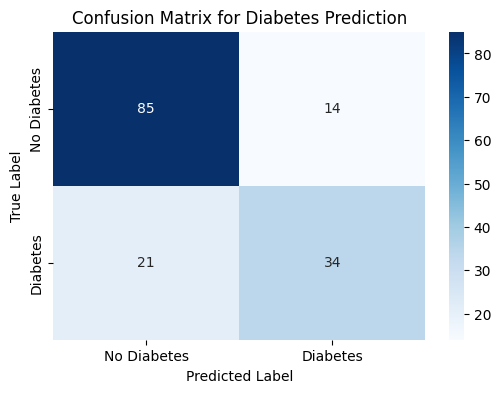

In [ ]:
print("Diabetes Prediction Model Evaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

# Generate and plot the Confusion Matrix (TP, FP, TN, FN)
cm = confusion_matrix(y_test_a, y_pred_a)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for Diabetes Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()